In [1]:
%run "00 Functions.ipynb"

## Preprocessing

## Zonal Values

In [2]:
RR_CR_dct = {"condo": "RR", "house": "RR", "apartment":"RR", "commercial":"CR", "land":"CR"}
qgis_df["Property Type"] = qgis_df["Category"].map(RR_CR_dct)

## Regularization

### Hyperparameter Tuning

general_df


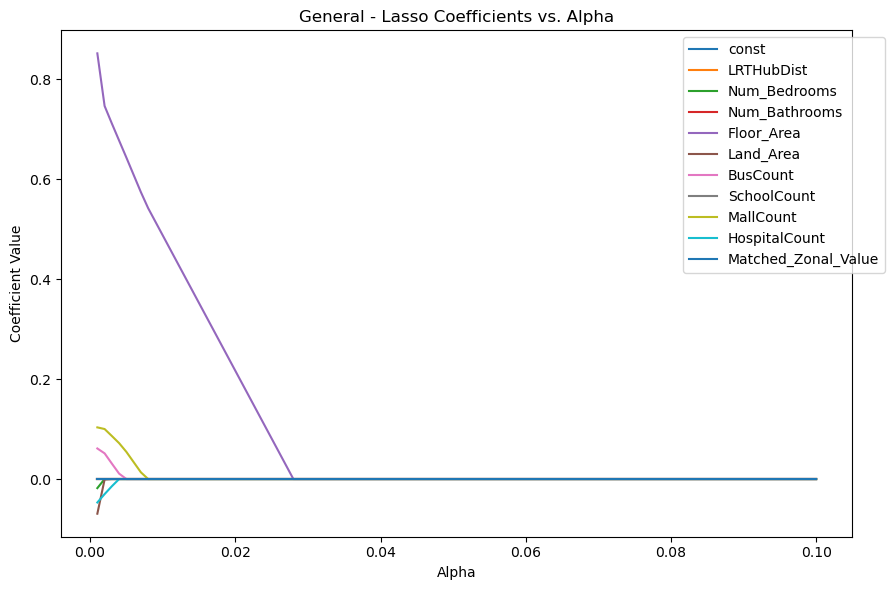



Property Type - RR


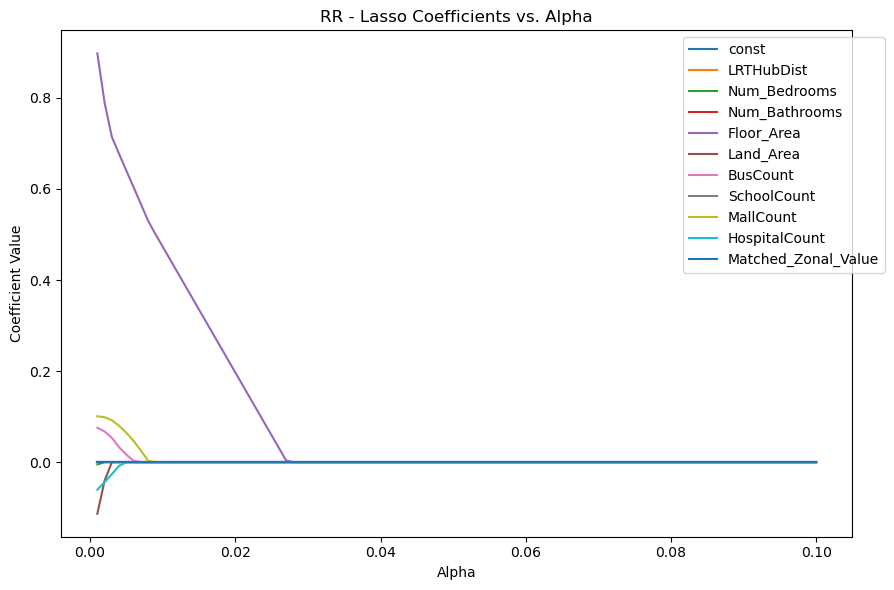



Property Type - CR


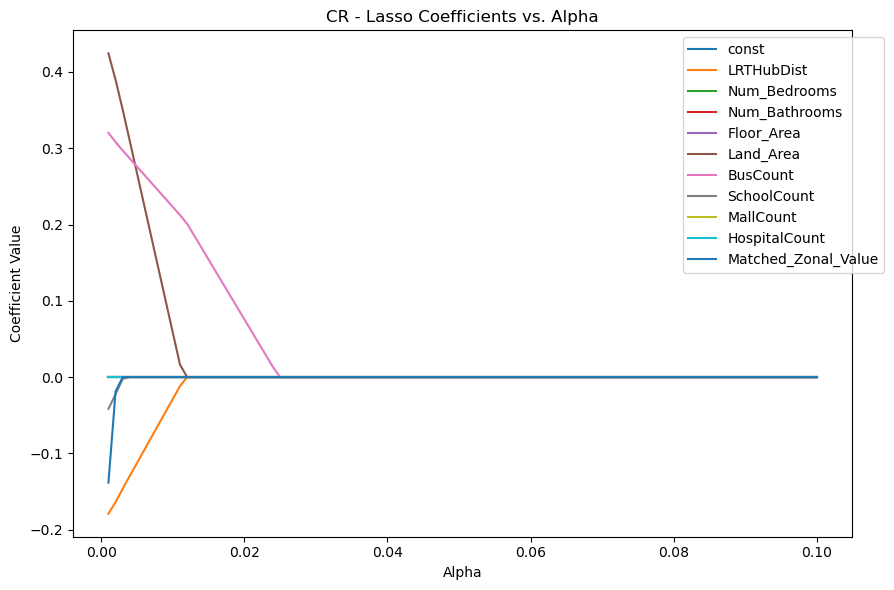



Category - house


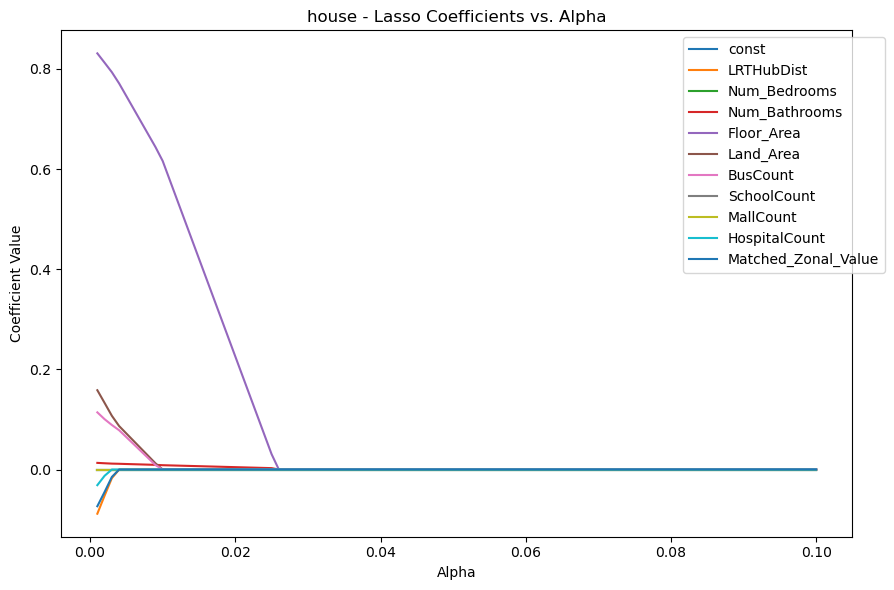



Category - condo


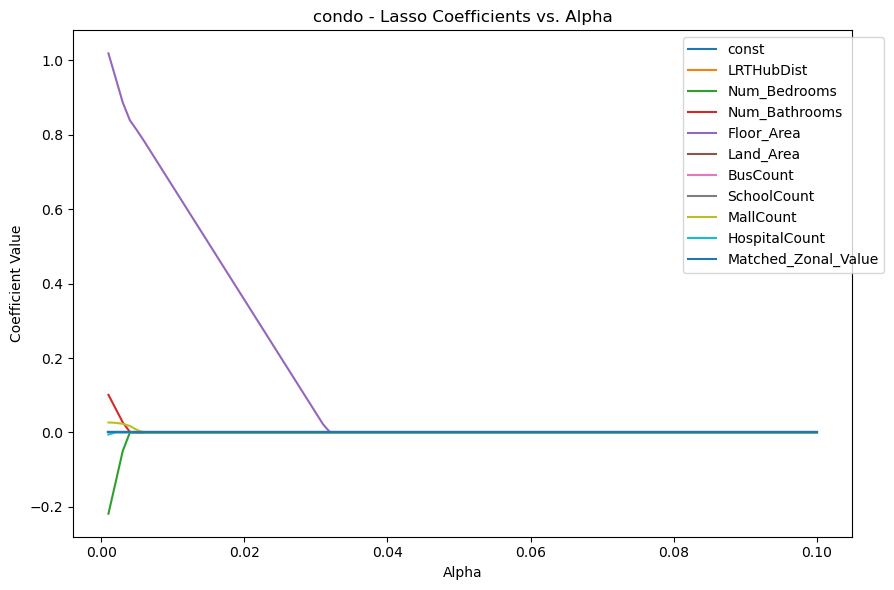



Category - apartment


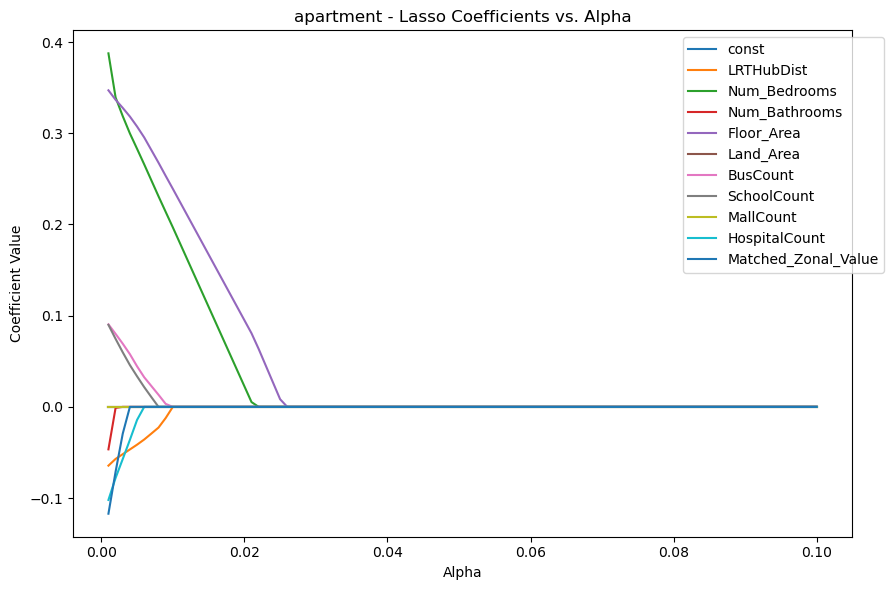



Category - land


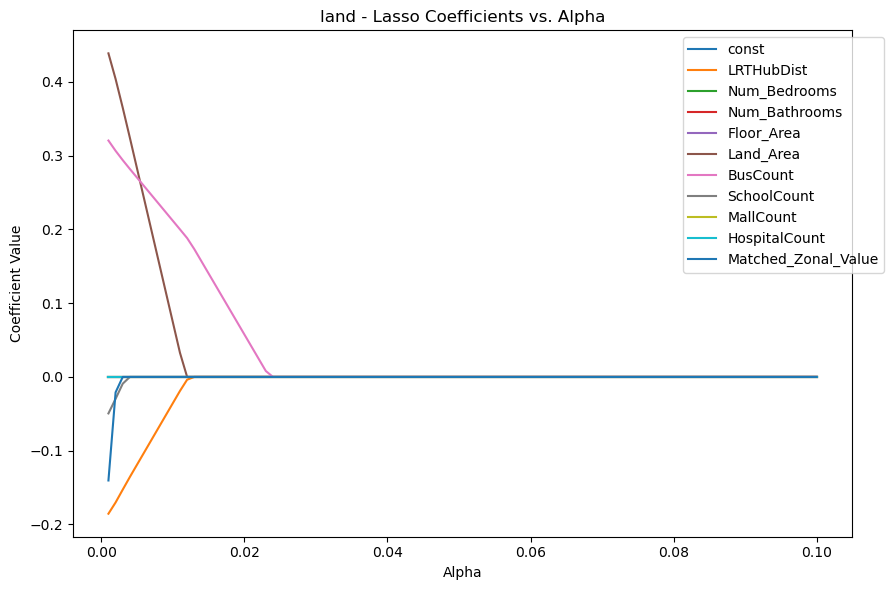



Category - commercial


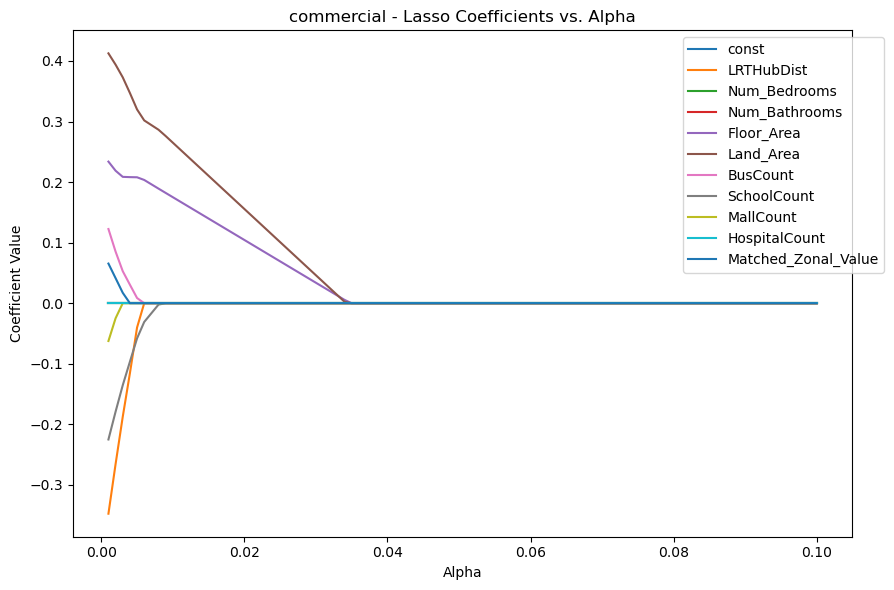

In [3]:
alpha_range = np.linspace(0.001, 0.1, 100)

print("general_df")
plot_lasso_coefficients_over_alpha("General", alpha_range, general_df, "count", True, True)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        plot_lasso_coefficients_over_alpha(category, alpha_range, category_df, "count", True, True)

### Ridge Regularization

In [4]:
regularization_type = "ridge"
alpha = 1.0
n=6
print(n)
print("general_df")
basic_model2_with_feature_selection(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        basic_model2_with_feature_selection(regularization_type, alpha, category_df, "count", True, True, n)

6
general_df
R-squared (R²): 0.5093
{'BusCount': 0.01839444739814877, 'Land_Area': -0.036594973101378755, 'LRTHubDist': 0.0009685134953697654, 'Num_Bedrooms': -0.0435353151344102, 'Floor_Area': 0.19844756672396488, 'Num_Bathrooms': 0.01301420410150013}


Property Type - RR
R-squared (R²): 0.5153
{'BusCount': 0.021035589593112445, 'Land_Area': -0.05244489368897747, 'LRTHubDist': 0.000315340045933423, 'Floor_Area': 0.20463074887415084, 'Num_Bedrooms': -0.04012288785342952, 'Num_Bathrooms': 0.014941071320133625}


Property Type - CR
R-squared (R²): 0.2793
{'BusCount': 0.07817004684644804, 'LRTHubDist': -0.009330791937137732, 'Land_Area': 0.08173048386964991, 'Floor_Area': 0.0, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0}


Category - house
R-squared (R²): 0.6691
{'BusCount': 0.028906737671187316, 'LRTHubDist': -0.003037621893750961, 'Land_Area': 0.03421378165732282, 'Num_Bathrooms': 0.004025919573656198, 'Num_Bedrooms': -0.0037253065544865013, 'Floor_Area': 0.13777787095666275}


Category -

In [5]:
regularization_type = "ridge"
alpha = 1.0
n = 2  # Initially choose n, but the best n will be determined in the function
print("general_df")
best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, category_df, "count", True, True, n)

general_df
Best R-squared (R²): 0.5365 with 8 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1936
Num_Bedrooms: -0.0356
Land_Area: -0.0287
MallCount: 0.0258
HospitalCount: -0.0182
BusCount: 0.0151
Num_Bathrooms: 0.0136
Matched_Zonal_Value: -0.0045


Property Type - RR
Best R-squared (R²): 0.5389 with 10 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.2011
Land_Area: -0.0434
Num_Bedrooms: -0.0311
MallCount: 0.0258
BusCount: 0.0199
HospitalCount: -0.0199
Num_Bathrooms: 0.0144
SchoolCount: -0.0023
Matched_Zonal_Value: -0.0023
LRTHubDist: 0.0019


Property Type - CR
Best R-squared (R²): 0.2930 with 4 features selected

Ranked Features (Based on coefficient):
Land_Area: 0.0802
BusCount: 0.0791
LRTHubDist: -0.0545
Matched_Zonal_Value: -0.0215


Category - house
Best R-squared (R²): 0.6879 with 8 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1350
Land_Area: 0.0377
BusCount: 0.0305
LRTHubDist: -0.0222
Matched_Zonal_V

### Lasso Regularization

In [6]:
regularization_type = "lasso"
alpha = 0.1 #Keep more features. Not very good results for 1.
n=6
print(n)
print("general_df")
basic_model2_with_feature_selection(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        basic_model2_with_feature_selection(regularization_type, alpha, category_df, "count", True, True, n)

6
general_df
R-squared (R²): 0.2543
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.04621961429346776, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0, 'LRTHubDist': -0.0}


Property Type - RR
R-squared (R²): 0.2334
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.04236434500811808, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0, 'LRTHubDist': -0.0}


Property Type - CR
R-squared (R²): -0.0003
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.0, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0, 'LRTHubDist': -0.0}


Category - house
R-squared (R²): 0.3955
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.06238081630453774, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0, 'LRTHubDist': -0.0}


Category - condo
R-squared (R²): 0.4130
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.07400565561502288, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0, 'LRTHubDist': -0.0}


Category - apartment
R-squared (R²): -0.0604
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.019547088360327782, 'Num_Bathrooms': 0

In [7]:
regularization_type = "lasso"
alpha = 0.01
count_distance = "count"
n = 2  # Initially choose n, but the best n will be determined in the function
print("general_df")
best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, general_df, count_distance, True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, category_df, count_distance, True, True, n)

general_df
Best R-squared (R²): 0.5115 with 6 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1432
MallCount: 0.0238
BusCount: 0.0106
HospitalCount: -0.0054
SchoolCount: -0.0000
Matched_Zonal_Value: -0.0000


Property Type - RR
Best R-squared (R²): 0.5182 with 7 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1488
MallCount: 0.0250
BusCount: 0.0152
HospitalCount: -0.0094
Land_Area: -0.0086
SchoolCount: 0.0000
Matched_Zonal_Value: -0.0000


Property Type - CR
Best R-squared (R²): 0.2816 with 4 features selected

Ranked Features (Based on coefficient):
BusCount: 0.0721
Land_Area: 0.0681
LRTHubDist: -0.0449
Matched_Zonal_Value: -0.0124


Category - house
Best R-squared (R²): 0.6703 with 10 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1359
Land_Area: 0.0244
BusCount: 0.0207
LRTHubDist: -0.0103
Matched_Zonal_Value: -0.0093
Num_Bedrooms: 0.0000
Num_Bathrooms: 0.0000
SchoolCount: 0.0000
MallCount: -0.0000
HospitalCo

In [8]:
regularization_type = "lasso"
alpha = 0.01
count_distance = "distance"
n = 2  # Initially choose n, but the best n will be determined in the function
print("general_df")
best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, general_df, count_distance, True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, category_df, count_distance, True, True, n)

general_df
Best R-squared (R²): 0.5151 with 8 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1478
HospitalHubDist: 0.0218
MallHubDist: -0.0139
BusHubDist: -0.0097
Land_Area: -0.0063
Num_Bathrooms: 0.0000
SchoolHubDist: 0.0000
Matched_Zonal_Value: -0.0000


Property Type - RR
Best R-squared (R²): 0.5213 with 10 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.1546
HospitalHubDist: 0.0214
Land_Area: -0.0184
MallHubDist: -0.0164
BusHubDist: -0.0106
LRTHubDist: -0.0006
Num_Bedrooms: -0.0000
Num_Bathrooms: 0.0000
SchoolHubDist: -0.0000
Matched_Zonal_Value: -0.0000


Property Type - CR
Best R-squared (R²): 0.2816 with 7 features selected

Ranked Features (Based on coefficient):
Land_Area: 0.0710
BusHubDist: -0.0699
LRTHubDist: -0.0407
SchoolHubDist: 0.0250
HospitalHubDist: -0.0178
Matched_Zonal_Value: -0.0110
MallHubDist: -0.0031


Category - house
Best R-squared (R²): 0.6622 with 10 features selected

Ranked Features (Based on coefficient):


# END